In [1]:
XENIUM_DATA_DIR = '/global/scratch/users/fosterangus/MetabTravLR/Data/Xenium'
DATASET_NAME = 'Human_Prostate_Adenocarcinoma'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 193000 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_1.5', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'leiden_scVI_res_0.

/tmp/ipykernel_2775193/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


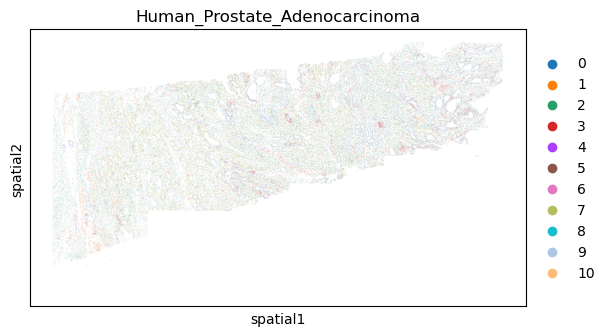

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

/tmp/ipykernel_2775193/1663927226.py:8: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)


Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 224.0
log_norm max (should be small, ~log scale): 9.210441


In [6]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

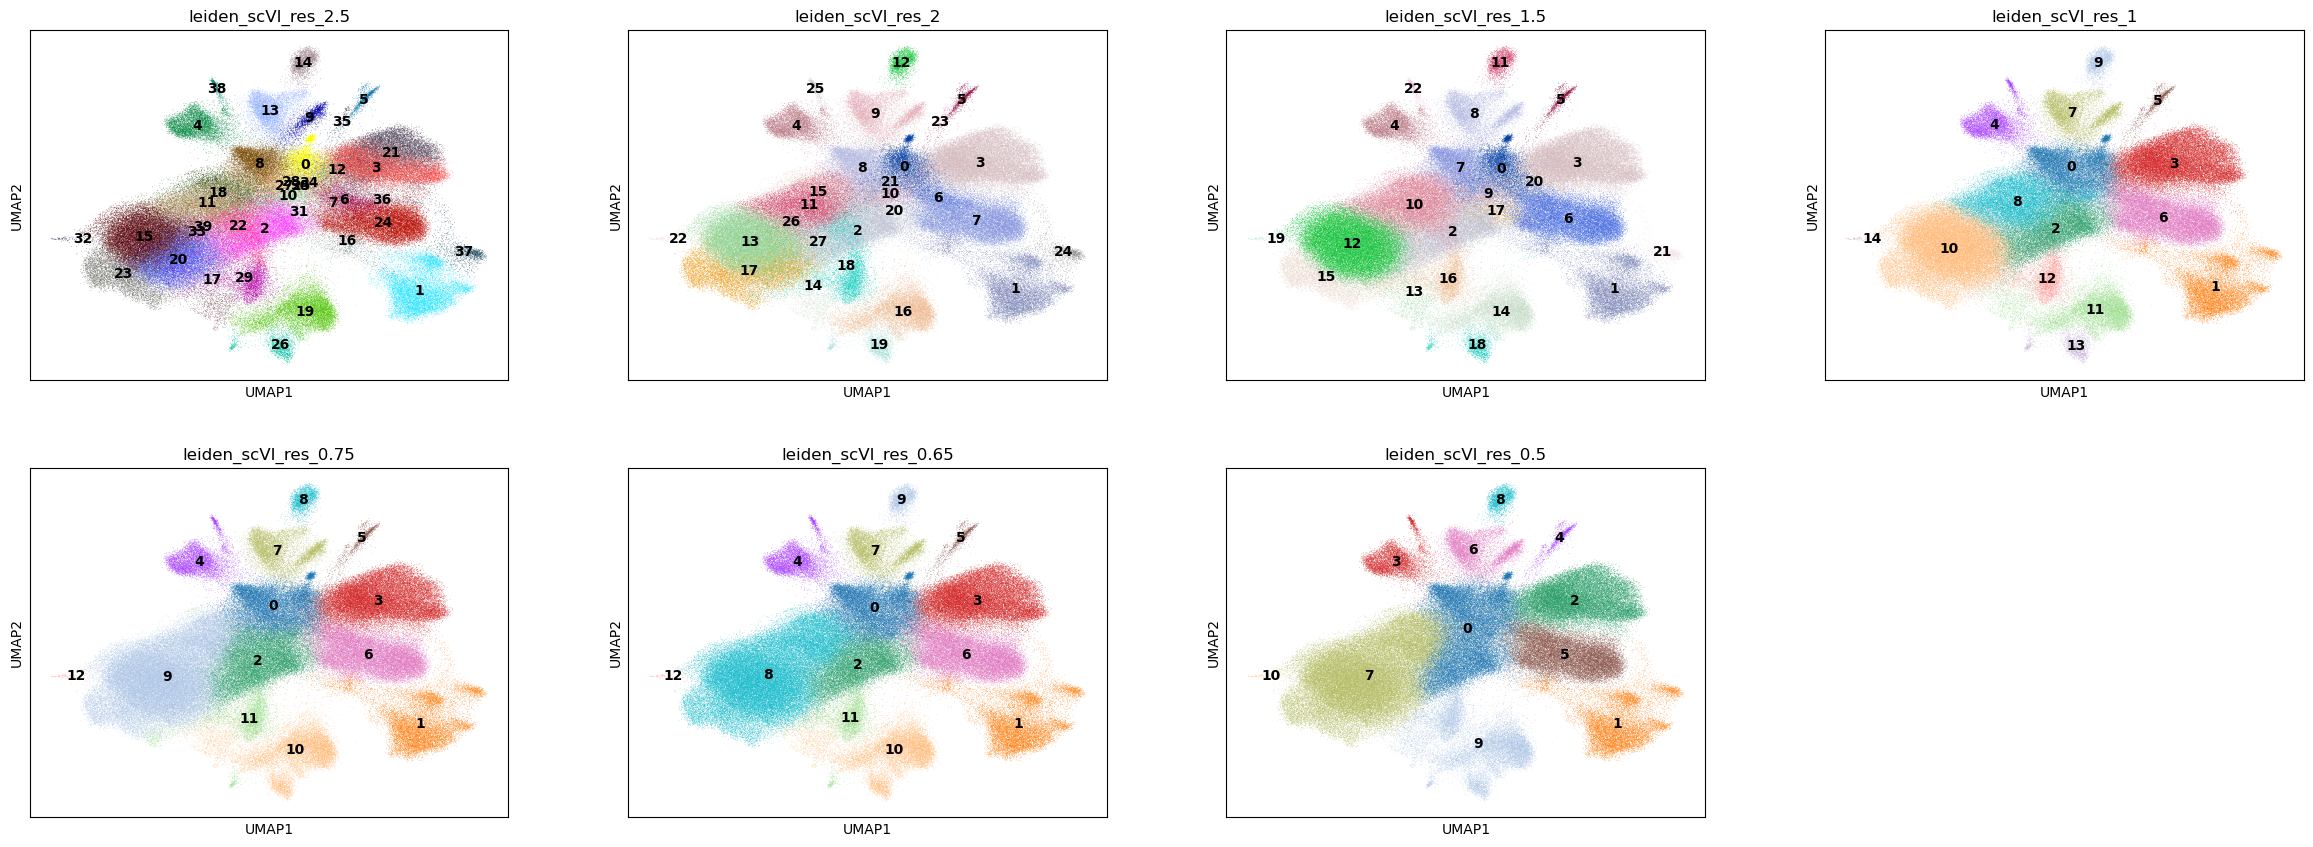

In [7]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['LBP', 'VAX1', 'CD5L', 'ZIC4', 'DAO', 'CMTM5', 'CYP2A6', 'TM4SF5', 'DDX53', 'GRIA1', 'PCK1', 'TFR2', 'F2', 'FGF19', 'MAGEC1']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SLC2A3', 'SOCS3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'MYH9', 'TGFBR2', 'CCL14']
Cluster 2: ['SNHG15', 'SOX2-OT', 'HOXB7', 'ANPEP', 'SPON2', 'P4HB', 'PCA3', 'SOST', 'ABCC4', 'NEFH', 'SORD', 'ACPP', 'POTEF', 'NKX3-1', 'IGFBP2']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'SMTN', 'SLMAP', 'CLIC4', 'SYNPO2', 'AOC3', 'COL4A2', 'FILIP1L', 'PDE5A', 'MXRA7', 'VCL']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'CD2', 'HECA', 'CD96', 'EEF1G', 'KLRB1', 'SH2D1A', 'SEPTIN9', 'FYN', 'CD44']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'H3F3B', 'PRNP', 'SPTBN1', 'MAL', 'NDRG2', 'ZFAND5']
Cluster 6: ['CCDC80', 'CCN2', 'DPT', 'SFRP1', 'TIMP2', 'H19', 'PI16', 'THBS1', 'CCN1', 'SF

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                              -0.002562            -0.003730   -0.000691   
1                              -0.031583             0.003933    0.038820   
2                              -0.009261            -0.018172   -0.014093   
3                              -0.019871            -0.009063   -0.000036   
4                               0.522767             0.444398    0.394642   
5                              -0.029544            -0.037930   -0.032504   
6                              -0.017567            -0.025729   -0.018337   
7                              -0.007721            -0.012986   -0.005644   
8                              -0.001296            -0.004421    0.003571   
9                              -0.012828            -0.003830    0.003437   
10        

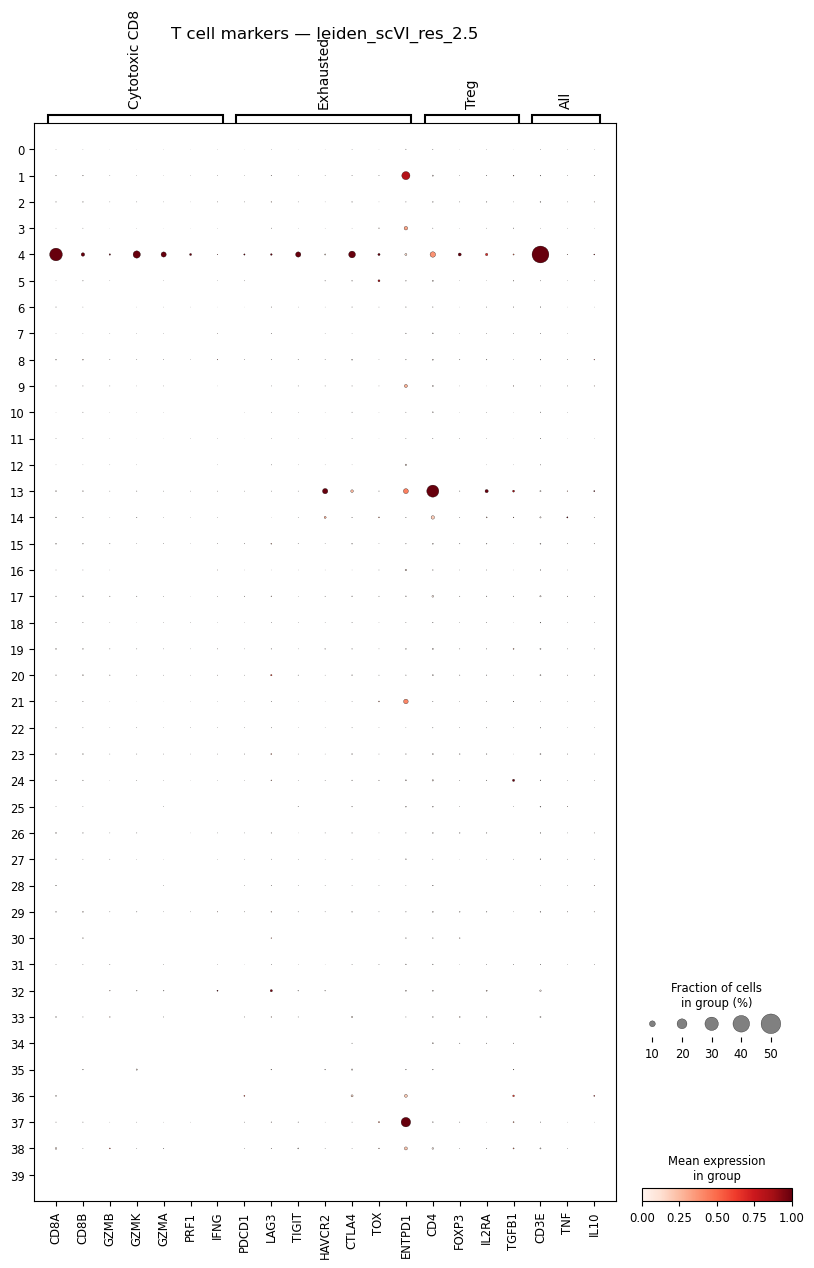


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['LBP', 'CYP2A6', 'CMTM5', 'CD5L', 'TM4SF5', 'DAO', 'ZIC4', 'GUCY2D', 'HTR1B', 'PCK1', 'F2', 'HTR2A', 'GRIA1', 'MUC16', 'MAGEC1']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SLC2A3', 'SOCS3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'TGFBR2', 'MYH9', 'CCL14']
Cluster 2: ['SNHG15', 'SOX2-OT', 'ANPEP', 'HOXB7', 'SPON2', 'P4HB', 'PCA3', 'ABCC4', 'SOST', 'SORD', 'ACPP', 'NEFH', 'NKX3-1', 'POTEF', 'IGFBP2']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SMTN', 'SLMAP', 'CLIC4', 'SYNPO2', 'FILIP1L', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'EEF1G', 'CD2', 'HECA', 'CD96', 'KLRB1', 'SH2D1A', 'SEPTIN9', 'FYN', 'CD44']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'PRNP', 'H3F3B', 'SPTBN1', 'MAL', 'NDRG2', 'ZFAND5']
Cluster 6: ['CCDC80', 'DPT', 'H19', 'PI16', 'TIMP2', 'SFRP1', 'SFRP4', 'CCN2', 'TNXB

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                            -0.003021            -0.004220   -0.000598   
1                            -0.028874             0.003181    0.035217   
2                            -0.009369            -0.019372   -0.015915   
3                            -0.022192            -0.009958   -0.000054   
4                             0.519843             0.442340    0.392515   
5                            -0.029395            -0.037843   -0.032515   
6                            -0.016434            -0.023342   -0.015043   
7                            -0.024511            -0.033698   -0.015705   
8                            -0.001102            -0.004557    0.002515   
9                            -0.017376             0.020892    0.142782   
10                           -0.00

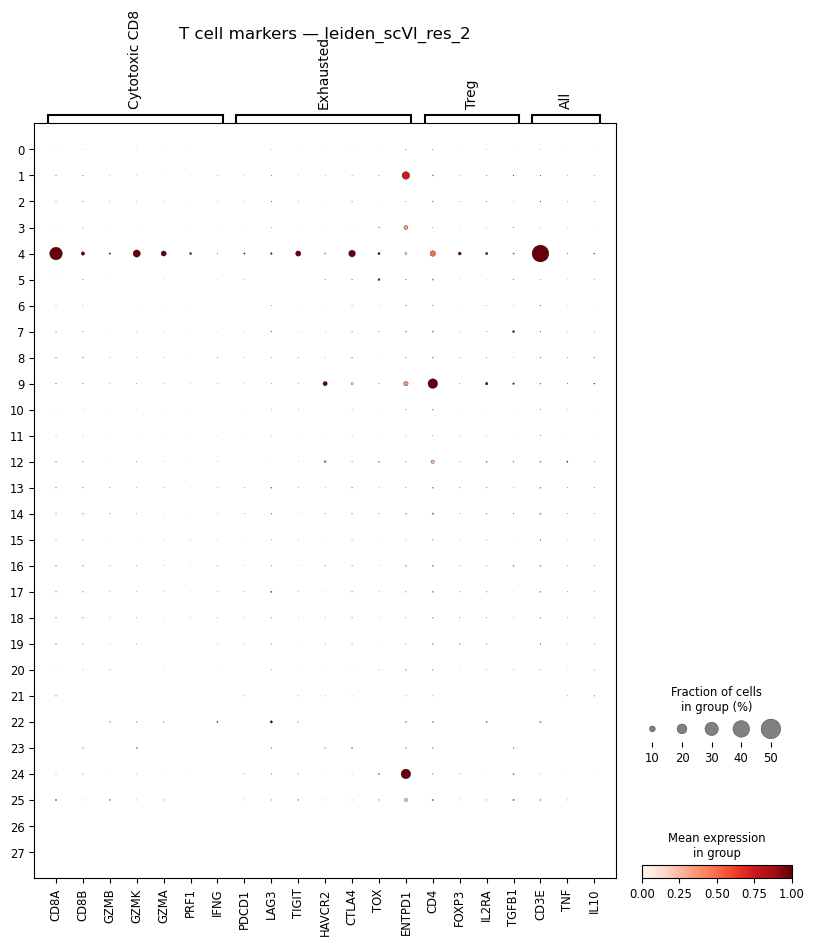


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CD5L', 'RFX4', 'CYP2A6', 'GRIA1', 'HTR2A', 'CMTM5', 'LBP', 'GUCY2D', 'ZIC4', 'HTR1B', 'F2', 'VSTM2B', 'TGM6', 'MUC16', 'MAGEC1']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SLC2A3', 'SOCS3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'TGFBR2', 'MYH9', 'CCL14']
Cluster 2: ['SNHG15', 'SOX2-OT', 'ANPEP', 'HOXB7', 'SPON2', 'P4HB', 'ABCC4', 'PCA3', 'SORD', 'ACPP', 'SOST', 'NEFH', 'NKX3-1', 'POTEF', 'IGFBP2']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SLMAP', 'SMTN', 'SYNPO2', 'CLIC4', 'FILIP1L', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'EEF1G', 'CD2', 'HECA', 'CD96', 'KLRB1', 'SH2D1A', 'SEPTIN9', 'FYN', 'CD44']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'H3F3B', 'PRNP', 'SPTBN1', 'MAL', 'NDRG2', 'ZFAND5']
Cluster 6: ['THBS1', 'CCN1', 'CCN2', 'SERPINE1', 'NR4A1', 'ADAMTS1', 'CCDC80', 'SFR

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                              -0.003175            -0.004695   -0.000197   
1                              -0.029277             0.003548    0.036033   
2                              -0.010099            -0.020414   -0.016768   
3                              -0.021527            -0.009625   -0.000044   
4                               0.519026             0.441456    0.391899   
5                              -0.029845            -0.038676   -0.032752   
6                              -0.023492            -0.032643   -0.015836   
7                              -0.001648            -0.004958    0.002028   
8                              -0.016875             0.021502    0.143695   
9                              -0.004281            -0.004285    0.000082   
10        

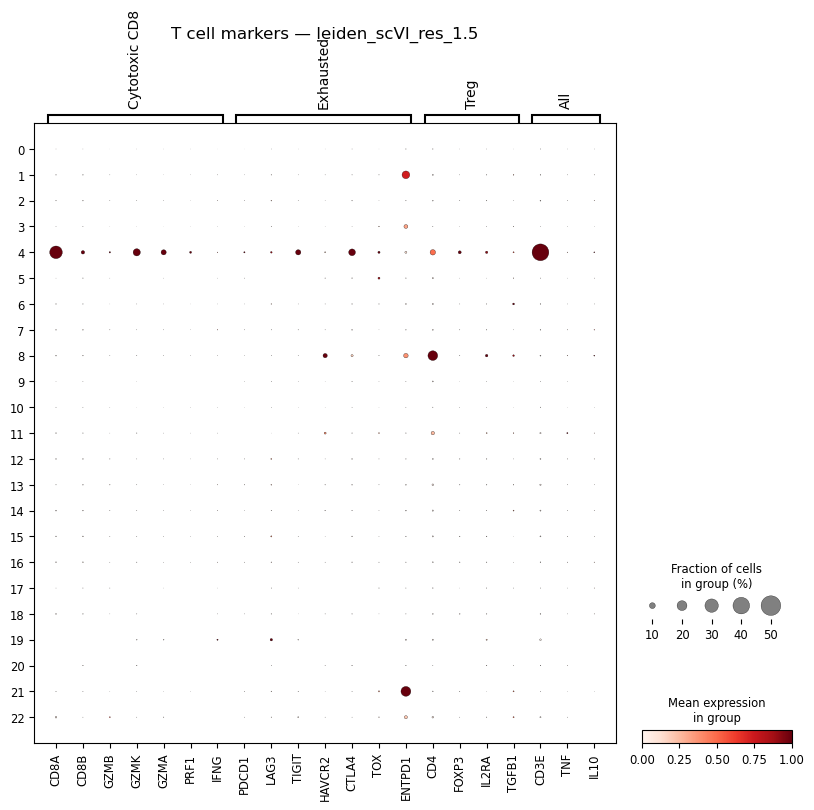


RESOLUTION: leiden_scVI_res_1

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['SOX2-OT', 'SOST', 'DUX4', 'F7', 'CDC27', 'EIF5AL1', 'TSPY1', 'TPTE', 'MUC19', 'HMGA2', 'DRD5', 'HTR4', 'NDST4', 'PSG1', 'PGA3']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SOCS3', 'SLC2A3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'MYH9', 'TGFBR2', 'CCL14']
Cluster 2: ['SNHG15', 'SOX2-OT', 'ANPEP', 'HOXB7', 'SPON2', 'P4HB', 'NEFH', 'ABCC4', 'PCA3', 'ACPP', 'SORD', 'SOST', 'NKX3-1', 'IGFBP2', 'POTEF']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SMTN', 'SYNPO2', 'SLMAP', 'FILIP1L', 'CLIC4', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'HECA', 'EEF1G', 'CD2', 'CD96', 'KLRB1', 'SMAP2', 'IL2RG', 'SH2D1A', 'SEPTIN9']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'PRNP', 'H3F3B', 'SPTBN1', 'NDRG2', 'NCAM1', 'MAL']
Cluster 6: ['THBS1', 'CCN1', 'CCN2', 'SERPINE1', 'N

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                            -0.002026            -0.004287    0.001468   
1                            -0.030702             0.003752    0.036719   
2                            -0.008859            -0.018083   -0.014528   
3                            -0.021099            -0.009609   -0.000263   
4                             0.481824             0.409632    0.363534   
5                            -0.030683            -0.039964   -0.037593   
6                            -0.022351            -0.031340   -0.015114   
7                            -0.017145             0.021443    0.144322   
8                            -0.009289            -0.018865   -0.017238   
9                            -0.017116            -0.020745    0.001901   
10                           -0.02

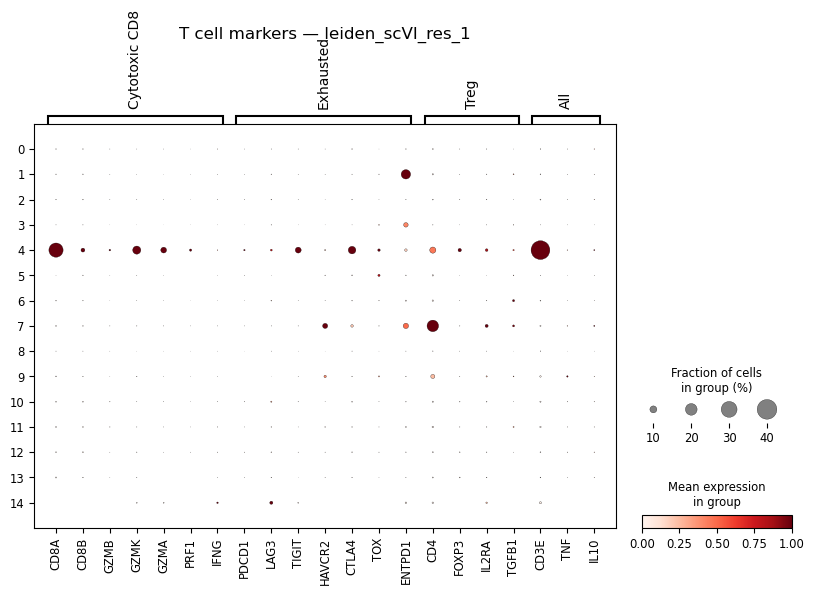


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['SOX2-OT', 'SOST', 'DUX4', 'F7', 'TSPY1', 'EIF5AL1', 'CDC27', 'TPTE', 'MUC19', 'DRD5', 'HTR4', 'HMGA2', 'NDST4', 'GABRA2', 'PGA3']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SOCS3', 'SLC2A3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'MYH9', 'TGFBR2', 'CCL14']
Cluster 2: ['SNHG15', 'HOXB7', 'ANPEP', 'SOX2-OT', 'SPON2', 'P4HB', 'NEFH', 'PCA3', 'SORD', 'ACPP', 'ABCC4', 'NKX3-1', 'IGFBP2', 'PCGEM1', 'SOST']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SMTN', 'SYNPO2', 'SLMAP', 'FILIP1L', 'CLIC4', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'EEF1G', 'HECA', 'CD2', 'CD96', 'KLRB1', 'IL2RG', 'SMAP2', 'SH2D1A', 'SEPTIN9']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'PRNP', 'H3F3B', 'SPTBN1', 'NDRG2', 'NCAM1', 'ZFAND5']
Cluster 6: ['THBS1', 'CCN1', 'CCN2', 'SERP

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                               -0.002381            -0.004592    0.001323   
1                               -0.030850             0.003640    0.036485   
2                               -0.007855            -0.016276   -0.012803   
3                               -0.020915            -0.009637   -0.000298   
4                                0.478585             0.406950    0.361040   
5                               -0.030777            -0.040101   -0.037747   
6                               -0.022211            -0.031158   -0.014921   
7                               -0.017392             0.021688    0.145259   
8                               -0.017063            -0.020699    0.001404   
9                               -0.024711            -0.046132   -0.045889  

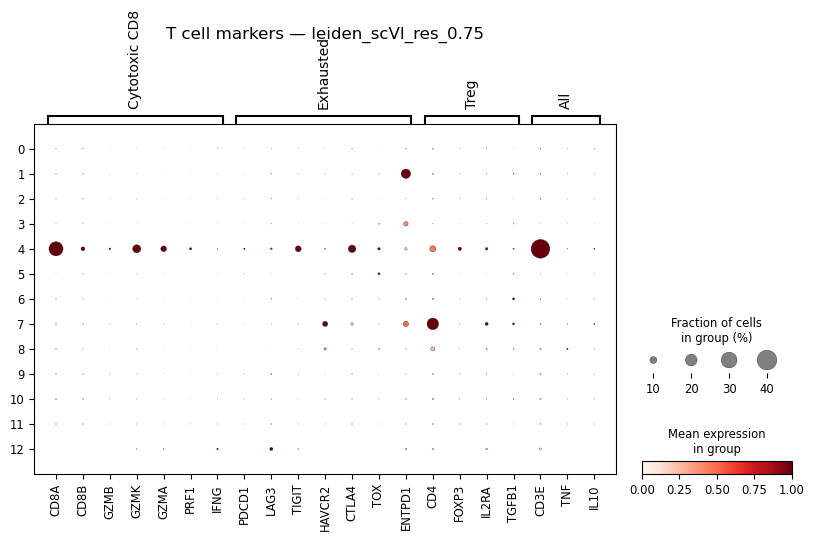


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['SOX2-OT', 'SOST', 'DUX4', 'F7', 'EIF5AL1', 'TSPY1', 'TPTE', 'MUC19', 'DRD5', 'HTR4', 'NDST4', 'HMGA2', 'PGA3', 'PSG1', 'GABRA2']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SOCS3', 'SLC2A3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'MYH9', 'TGFBR2', 'CCL14']
Cluster 2: ['SNHG15', 'SOX2-OT', 'ANPEP', 'HOXB7', 'SPON2', 'NEFH', 'P4HB', 'ACPP', 'ABCC4', 'SORD', 'PCA3', 'SOST', 'NKX3-1', 'IGFBP2', 'POTEF']
Cluster 3: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SMTN', 'SYNPO2', 'SLMAP', 'FILIP1L', 'CLIC4', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 4: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'EEF1G', 'HECA', 'CD2', 'CD96', 'KLRB1', 'IL2RG', 'SMAP2', 'SH2D1A', 'SEPTIN9']
Cluster 5: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'PRNP', 'H3F3B', 'SPTBN1', 'NDRG2', 'NCAM1', 'ZFAND5']
Cluster 6: ['THBS1', 'CCN1', 'CCN2', 'SERPIN

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                               -0.002359            -0.004699    0.001209   
1                               -0.030842             0.003748    0.036586   
2                               -0.008412            -0.017237   -0.013666   
3                               -0.020987            -0.009659   -0.000209   
4                                0.480304             0.408290    0.362214   
5                               -0.030933            -0.040479   -0.037975   
6                               -0.022286            -0.031094   -0.014920   
7                               -0.017637             0.021497    0.145466   
8                               -0.023886            -0.044694   -0.044299   
9                               -0.017064            -0.020635    0.001477  

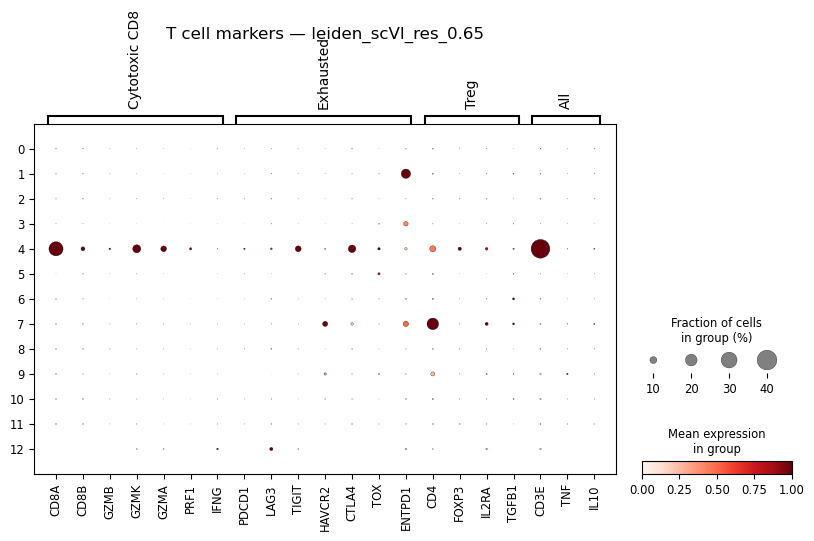


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['SOX2-OT', 'SNHG15', 'SOST', 'HOXB7', 'NEFH', 'SPON2', 'DUX4', 'F7', 'RLN1', 'PCGEM1', 'ZNF683', 'TMEFF2', 'TSPY1', 'TPTE', 'EIF5AL1']
Cluster 1: ['ADAMTS1', 'CDKN1A', 'EPAS1', 'EMP1', 'SOCS3', 'SLC2A3', 'CAVIN2', 'PLVAP', 'PECAM1', 'THBD', 'FAM107A', 'ADAMTS4', 'MYH9', 'TGFBR2', 'CCL14']
Cluster 2: ['MYLK', 'CSRP1', 'SYNM', 'HSPB8', 'FHL1', 'PDE5A', 'CCN2', 'SMTN', 'SYNPO2', 'SLMAP', 'FILIP1L', 'CLIC4', 'KCNMA1', 'COL4A2', 'MXRA7']
Cluster 3: ['CXCR4', 'CD3E', 'CD8A', 'ETS1', 'CDKN1B', 'IKZF1', 'EEF1G', 'HECA', 'CD2', 'CD96', 'KLRB1', 'SMAP2', 'IL2RG', 'SH2D1A', 'SEPTIN9']
Cluster 4: ['MPZ', 'PMP22', 'CLIC4', 'SCN7A', 'AHR', 'L1CAM', 'DST', 'HSPG2', 'SAMHD1', 'PRNP', 'NDRG2', 'H3F3B', 'SPTBN1', 'NCAM1', 'ZFAND5']
Cluster 5: ['THBS1', 'CCN1', 'CCN2', 'SERPINE1', 'NR4A1', 'ADAMTS1', 'CCDC80', 'SFRP1', 'DKK3', 'COL5A1', 'TIMP2', 'MEG3', 'EMP1', 'PDGFRA', 'OLFML3']
Cluster 6: ['FCGR2A', 'C5AR1', 'MRC

/tmp/ipykernel_2775193/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2775193/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                              -0.004178            -0.009076   -0.004324   
1                              -0.031003             0.003859    0.036866   
2                              -0.020930            -0.009542   -0.000182   
3                               0.481200             0.409196    0.363313   
4                              -0.031041            -0.040539   -0.038047   
5                              -0.022252            -0.031074   -0.014677   
6                              -0.017563             0.022137    0.146811   
7                              -0.023747            -0.044438   -0.043881   
8                              -0.017038            -0.020825    0.001389   
9                              -0.034129            -0.056614   -0.054164   
10        

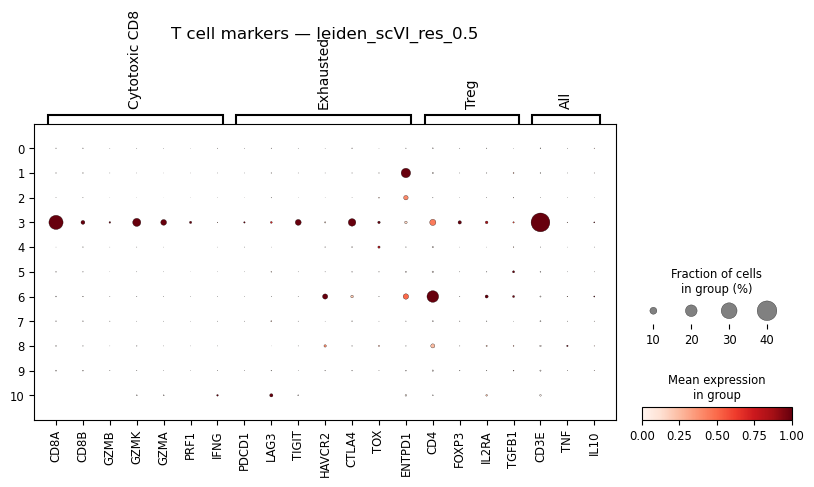

In [8]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [9]:
all_scores[res_label(0.75)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_0.75,,,,
0,-0.002381,-0.004592,0.001323,18444
1,-0.030850,0.003640,0.036485,13192
2,-0.007855,-0.016276,-0.012803,20330
3,-0.020915,-0.009637,-0.000298,28251
4,0.478585,0.406950,0.361040,6622
5,-0.030777,-0.040101,-0.037747,1229
6,-0.022211,-0.031158,-0.014921,22227
7,-0.017392,0.021688,0.145259,7750
8,-0.017063,-0.020699,0.001404,2435


/tmp/ipykernel_2775193/59807548.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


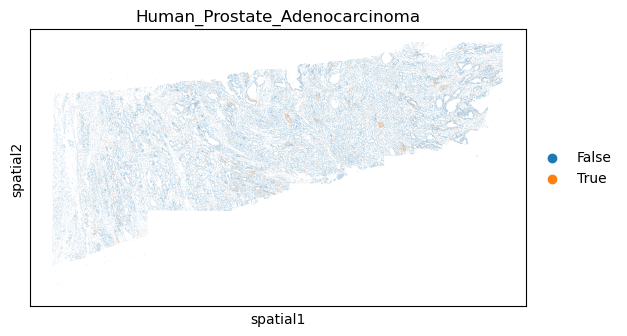

In [10]:
res = 0.75
cd8 = ['4'] #CD8
cd4 = ['7'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8) 
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts) 
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');

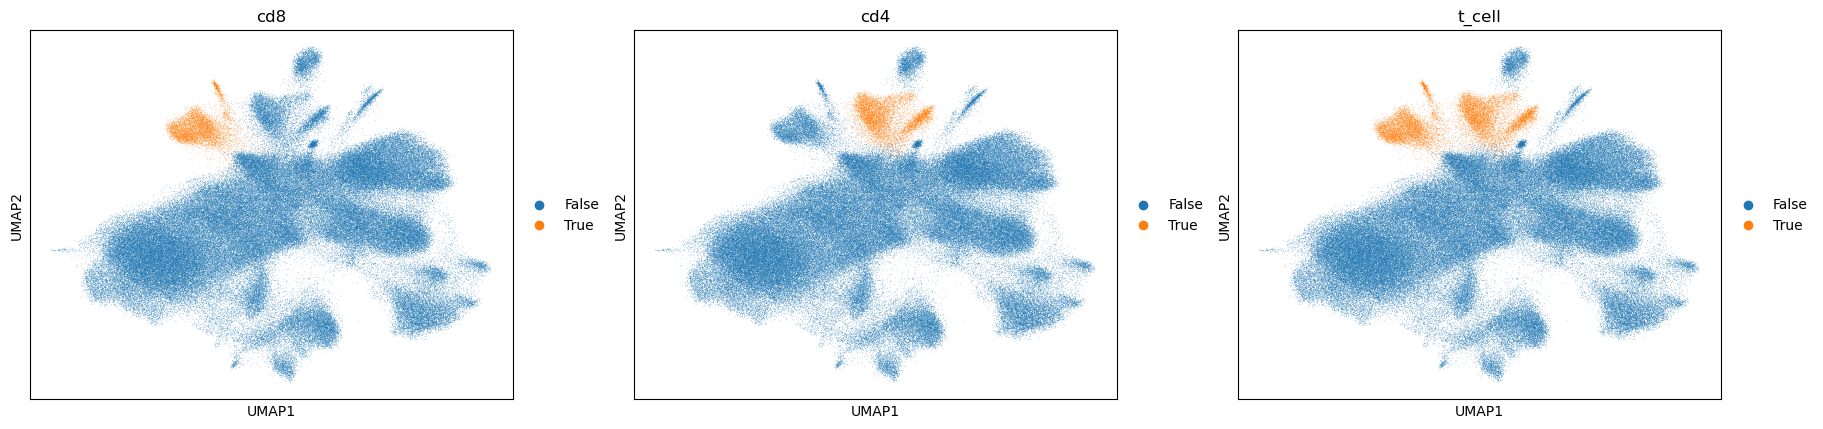

In [11]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [12]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 178628
t cell: 14372
cd8: 6622
cd4: 7750


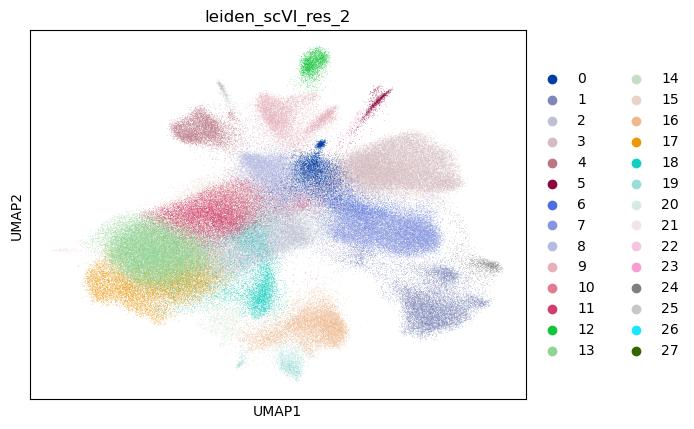

In [13]:
sc.pl.umap(adata, color=[res_label(2)])

In [14]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata

In [15]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

Starting Sub Resolutions 1


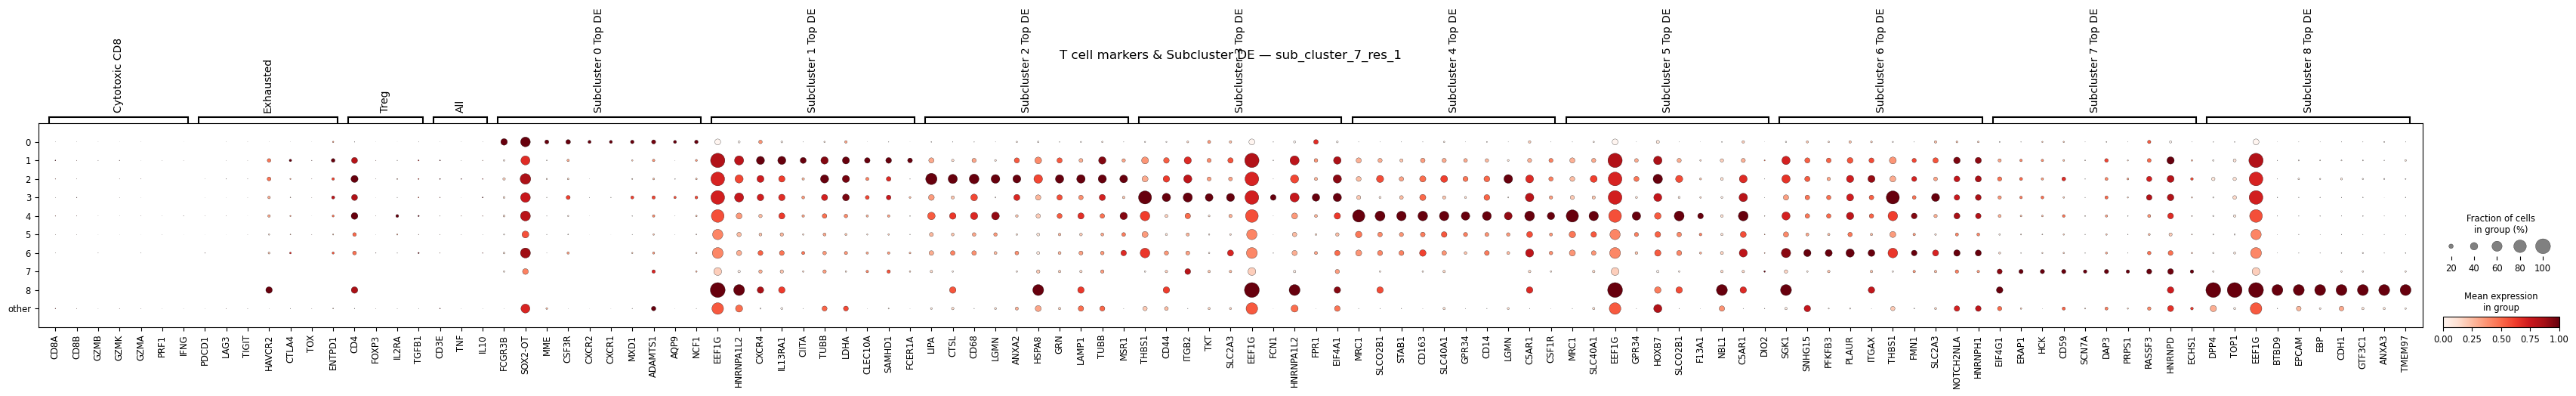


Sub-cluster sizes for sub_cluster_7_res_1:
sub_cluster_7_res_1
other    185250
0          2039
5          1847
4          1509
3           936
1           779
2           396
6           220
7            21
8             3
Name: count, dtype: int64
Starting Sub Resolutions 0.75


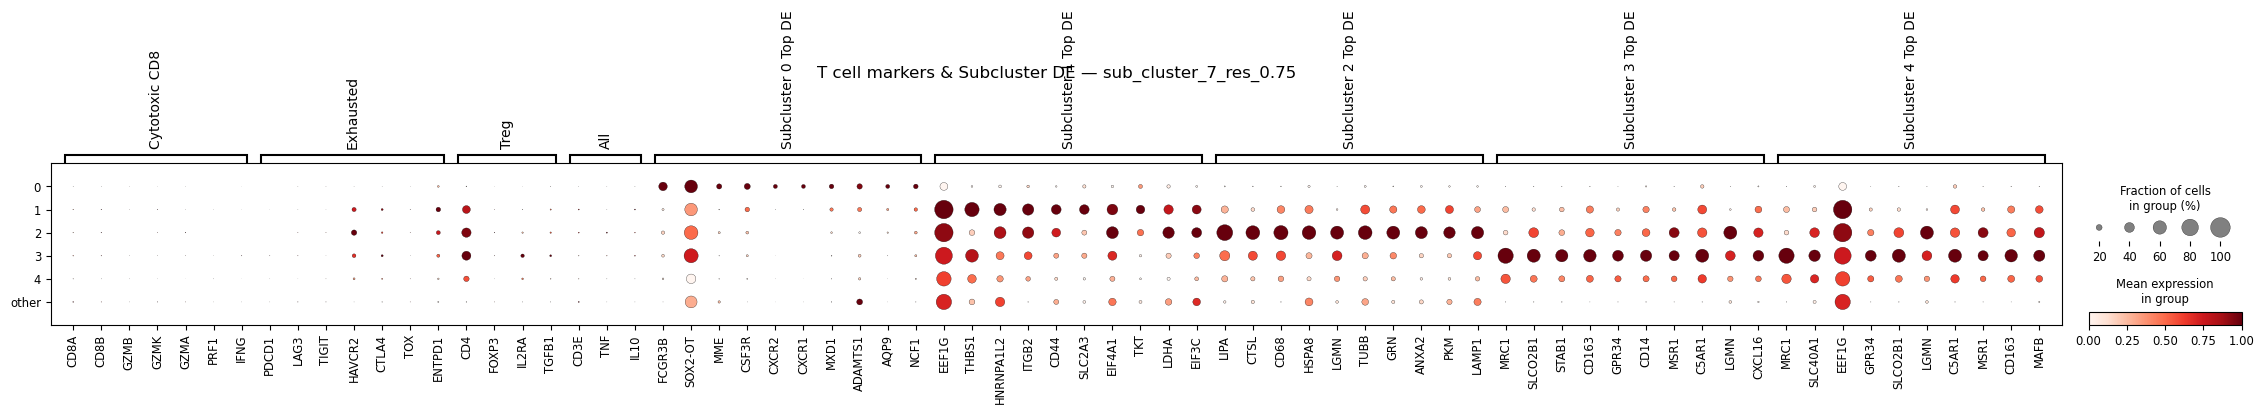


Sub-cluster sizes for sub_cluster_7_res_0.75:
sub_cluster_7_res_0.75
other    185250
4          2354
0          2104
1          1594
3          1470
2           228
Name: count, dtype: int64
Starting Sub Resolutions 0.5


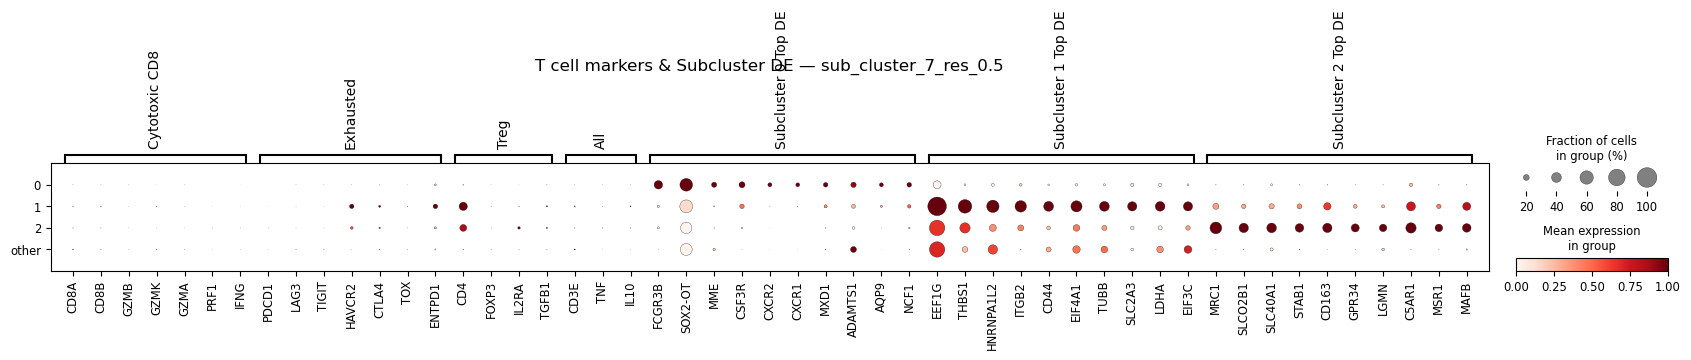


Sub-cluster sizes for sub_cluster_7_res_0.5:
sub_cluster_7_res_0.5
other    185250
2          3843
0          2133
1          1774
Name: count, dtype: int64
Starting Sub Resolutions 0.37


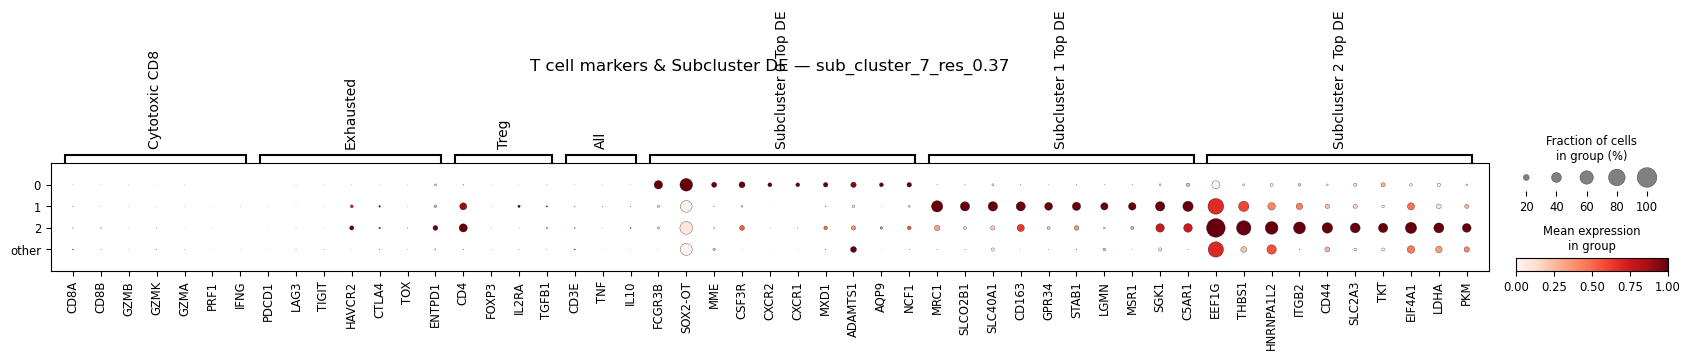


Sub-cluster sizes for sub_cluster_7_res_0.37:
sub_cluster_7_res_0.37
other    185250
1          4299
0          2134
2          1317
Name: count, dtype: int64
Starting Sub Resolutions 0.25


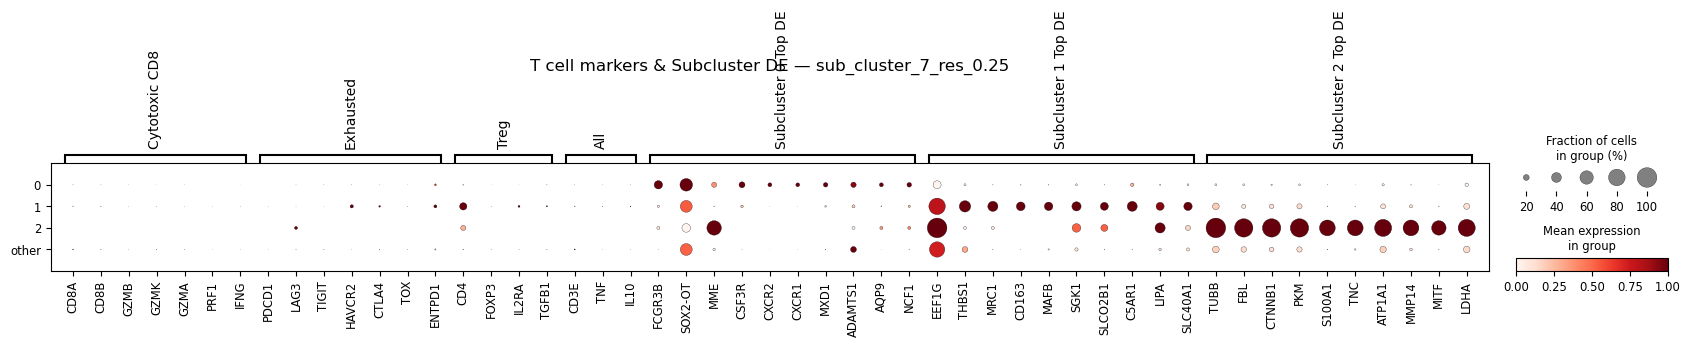


Sub-cluster sizes for sub_cluster_7_res_0.25:
sub_cluster_7_res_0.25
other    185250
1          5572
0          2166
2            12
Name: count, dtype: int64
Starting Sub Resolutions 0.15


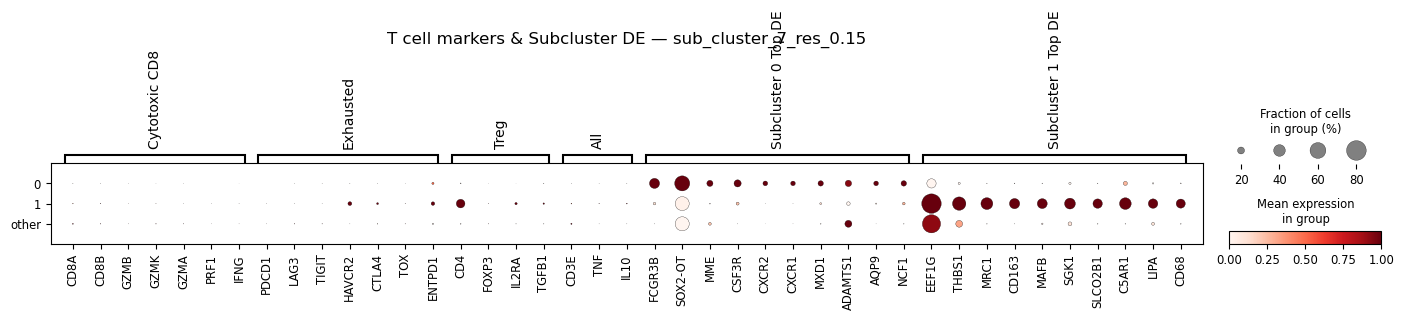


Sub-cluster sizes for sub_cluster_7_res_0.15:
sub_cluster_7_res_0.15
other    185250
1          5638
0          2112
Name: count, dtype: int64
Starting Sub Resolutions 0.1


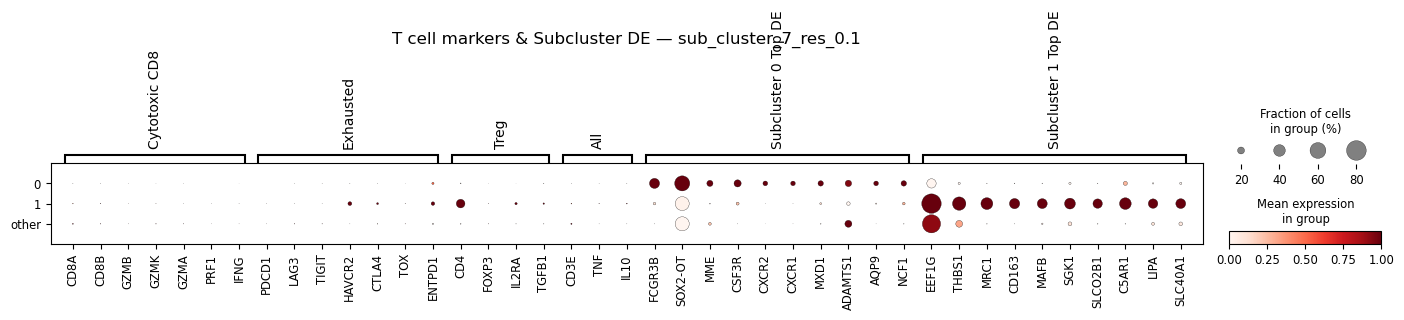


Sub-cluster sizes for sub_cluster_7_res_0.1:
sub_cluster_7_res_0.1
other    185250
1          5637
0          2113
Name: count, dtype: int64
Starting Sub Resolutions 0.05


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


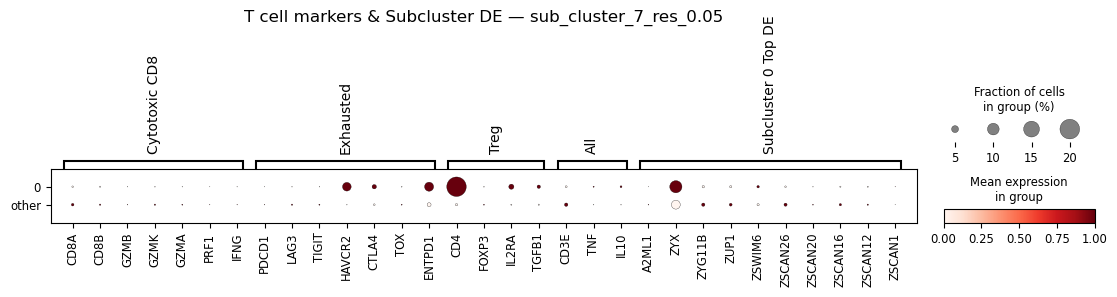


Sub-cluster sizes for sub_cluster_7_res_0.05:
sub_cluster_7_res_0.05
other    185250
0          7750
Name: count, dtype: int64


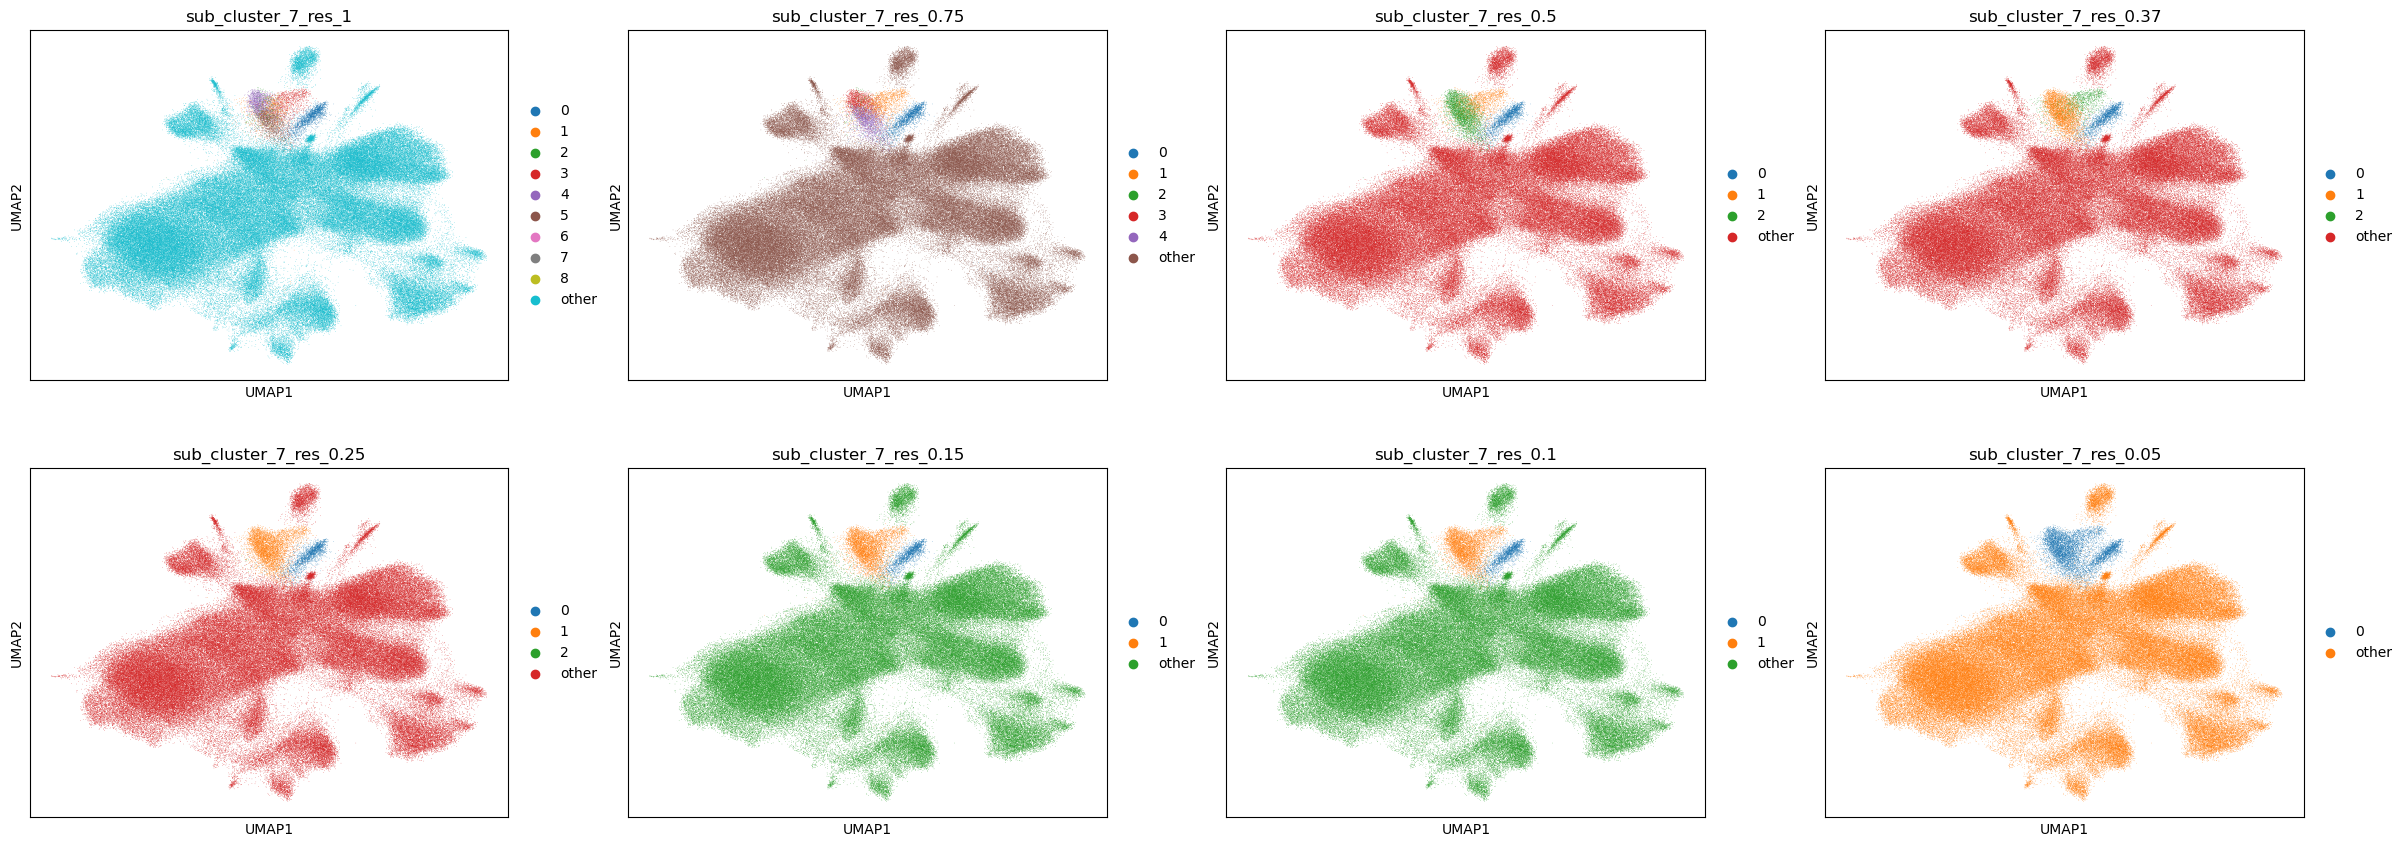

In [16]:
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

starting cd8
Starting Sub Resolutions 1


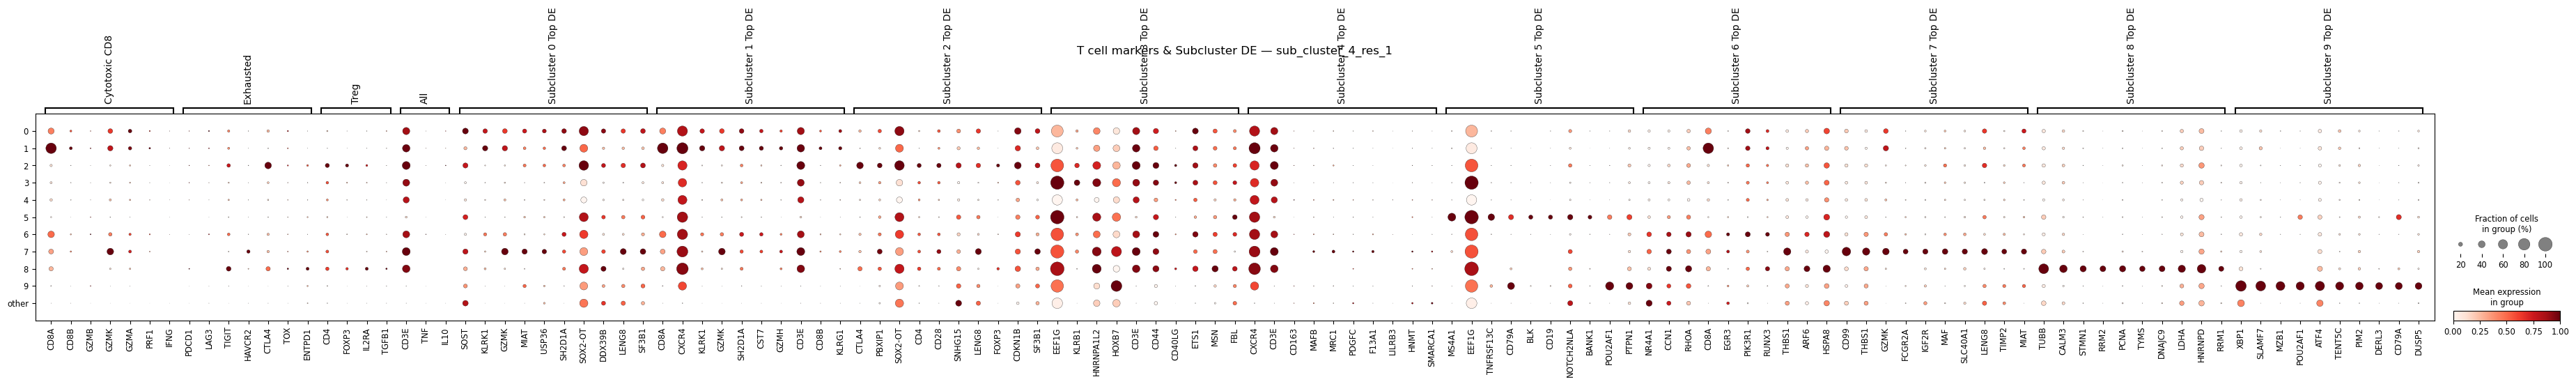


Sub-cluster sizes for sub_cluster_4_res_1:
sub_cluster_4_res_1
other    186378
1          1542
3          1266
2          1216
4           833
9           560
0           557
5           376
6           196
7            39
8            37
Name: count, dtype: int64
Starting Sub Resolutions 0.75


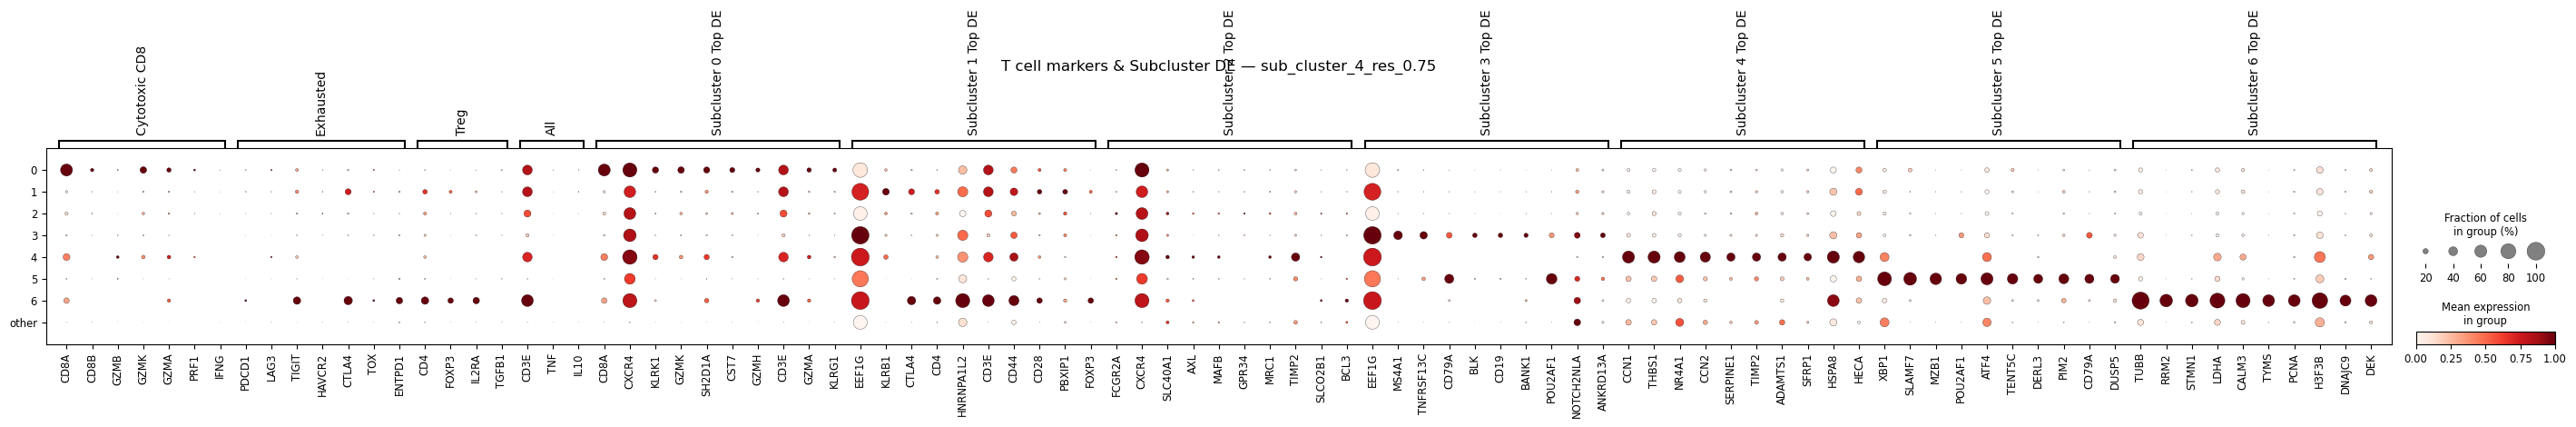


Sub-cluster sizes for sub_cluster_4_res_0.75:
sub_cluster_4_res_0.75
other    186378
1          2525
0          2432
2           562
5           562
3           497
4            25
6            19
Name: count, dtype: int64
Starting Sub Resolutions 0.5


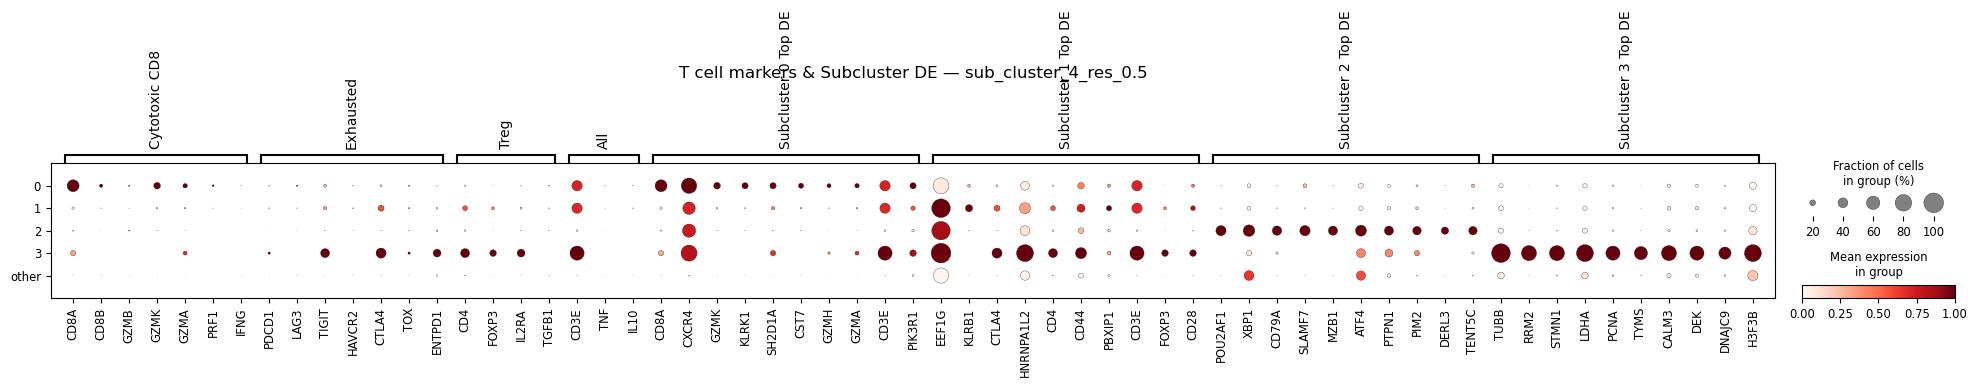


Sub-cluster sizes for sub_cluster_4_res_0.5:
sub_cluster_4_res_0.5
other    186378
0          2920
1          2806
2           879
3            17
Name: count, dtype: int64
Starting Sub Resolutions 0.37


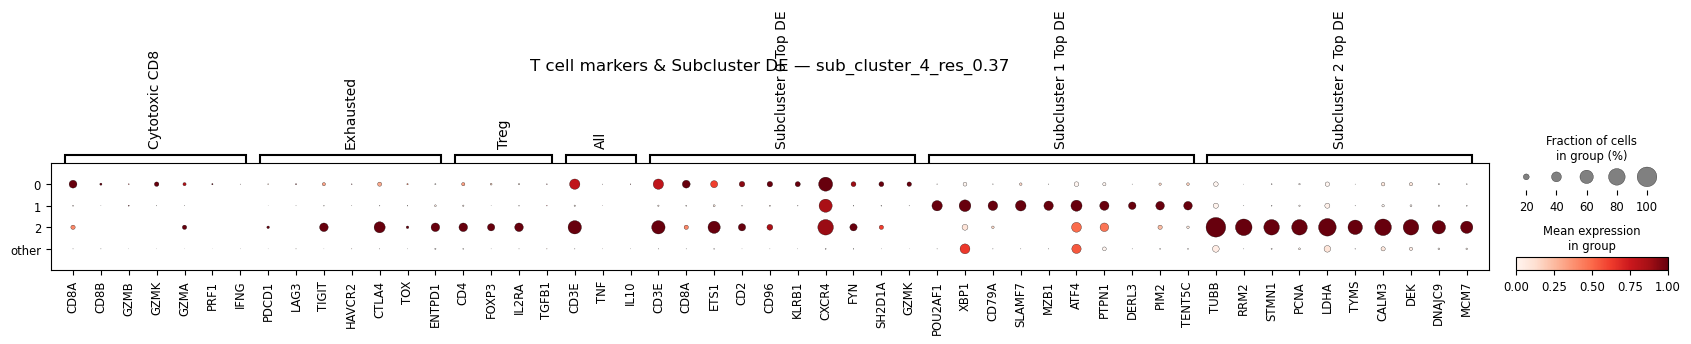


Sub-cluster sizes for sub_cluster_4_res_0.37:
sub_cluster_4_res_0.37
other    186378
0          5755
1           852
2            15
Name: count, dtype: int64
Starting Sub Resolutions 0.25


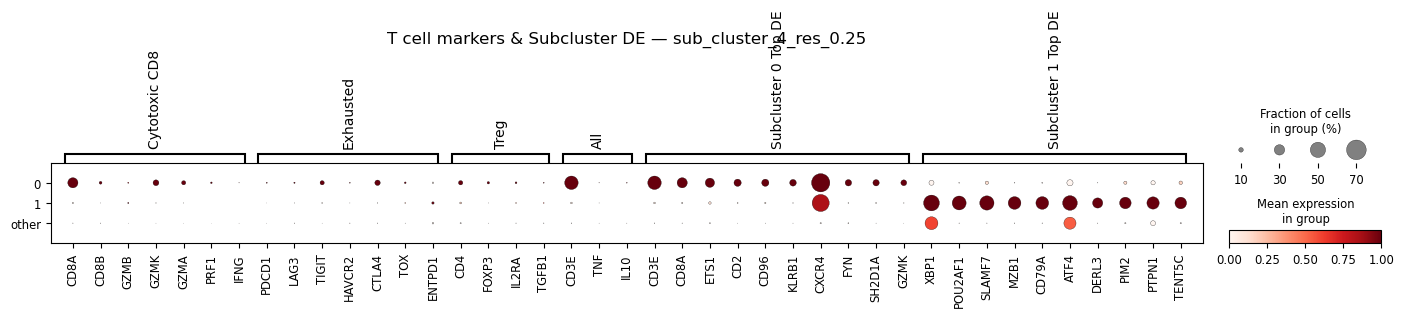


Sub-cluster sizes for sub_cluster_4_res_0.25:
sub_cluster_4_res_0.25
other    186378
0          5809
1           813
Name: count, dtype: int64
Starting Sub Resolutions 0.15


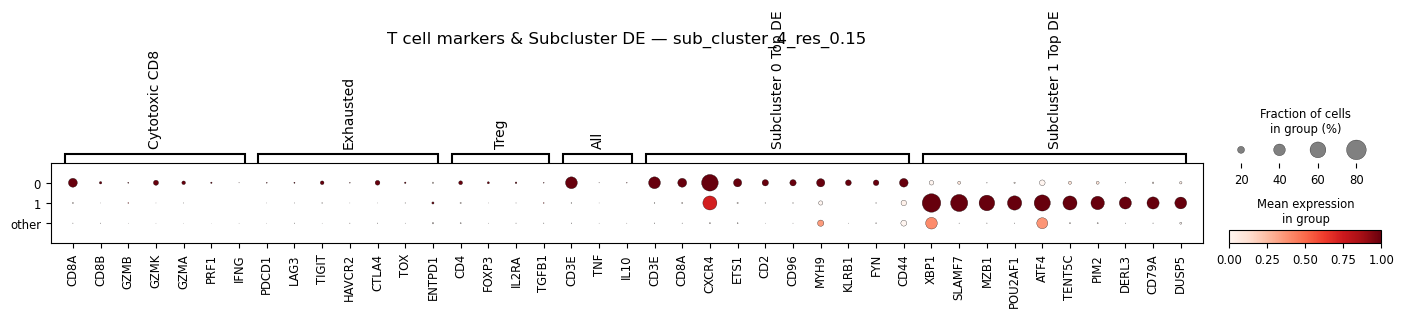


Sub-cluster sizes for sub_cluster_4_res_0.15:
sub_cluster_4_res_0.15
other    186378
0          6087
1           535
Name: count, dtype: int64
Starting Sub Resolutions 0.1


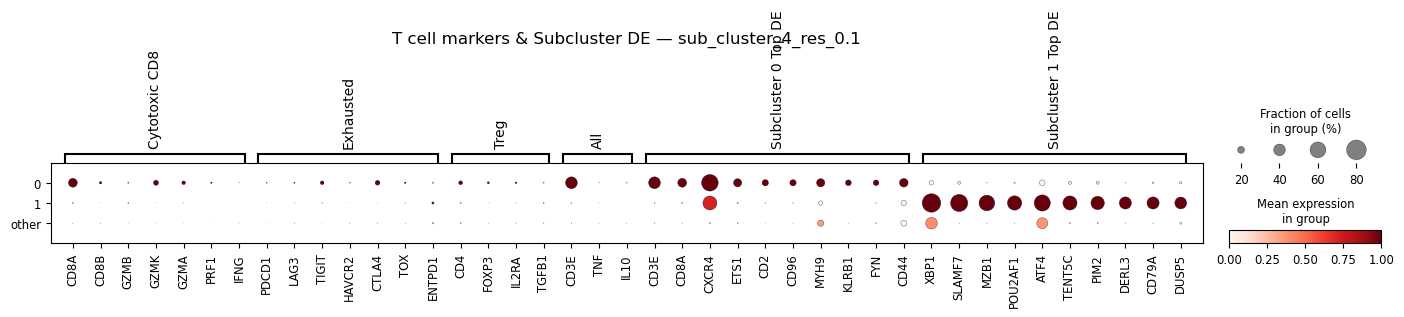


Sub-cluster sizes for sub_cluster_4_res_0.1:
sub_cluster_4_res_0.1
other    186378
0          6090
1           532
Name: count, dtype: int64
Starting Sub Resolutions 0.05


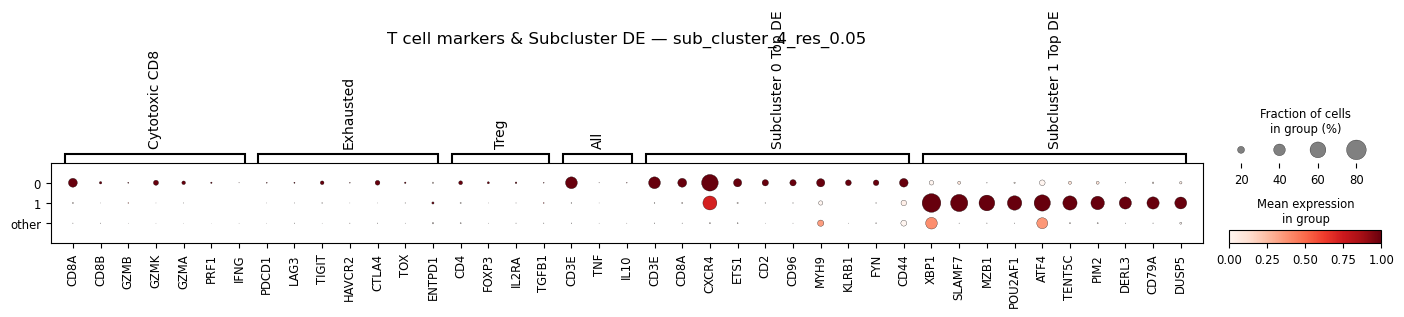


Sub-cluster sizes for sub_cluster_4_res_0.05:
sub_cluster_4_res_0.05
other    186378
0          6094
1           528
Name: count, dtype: int64


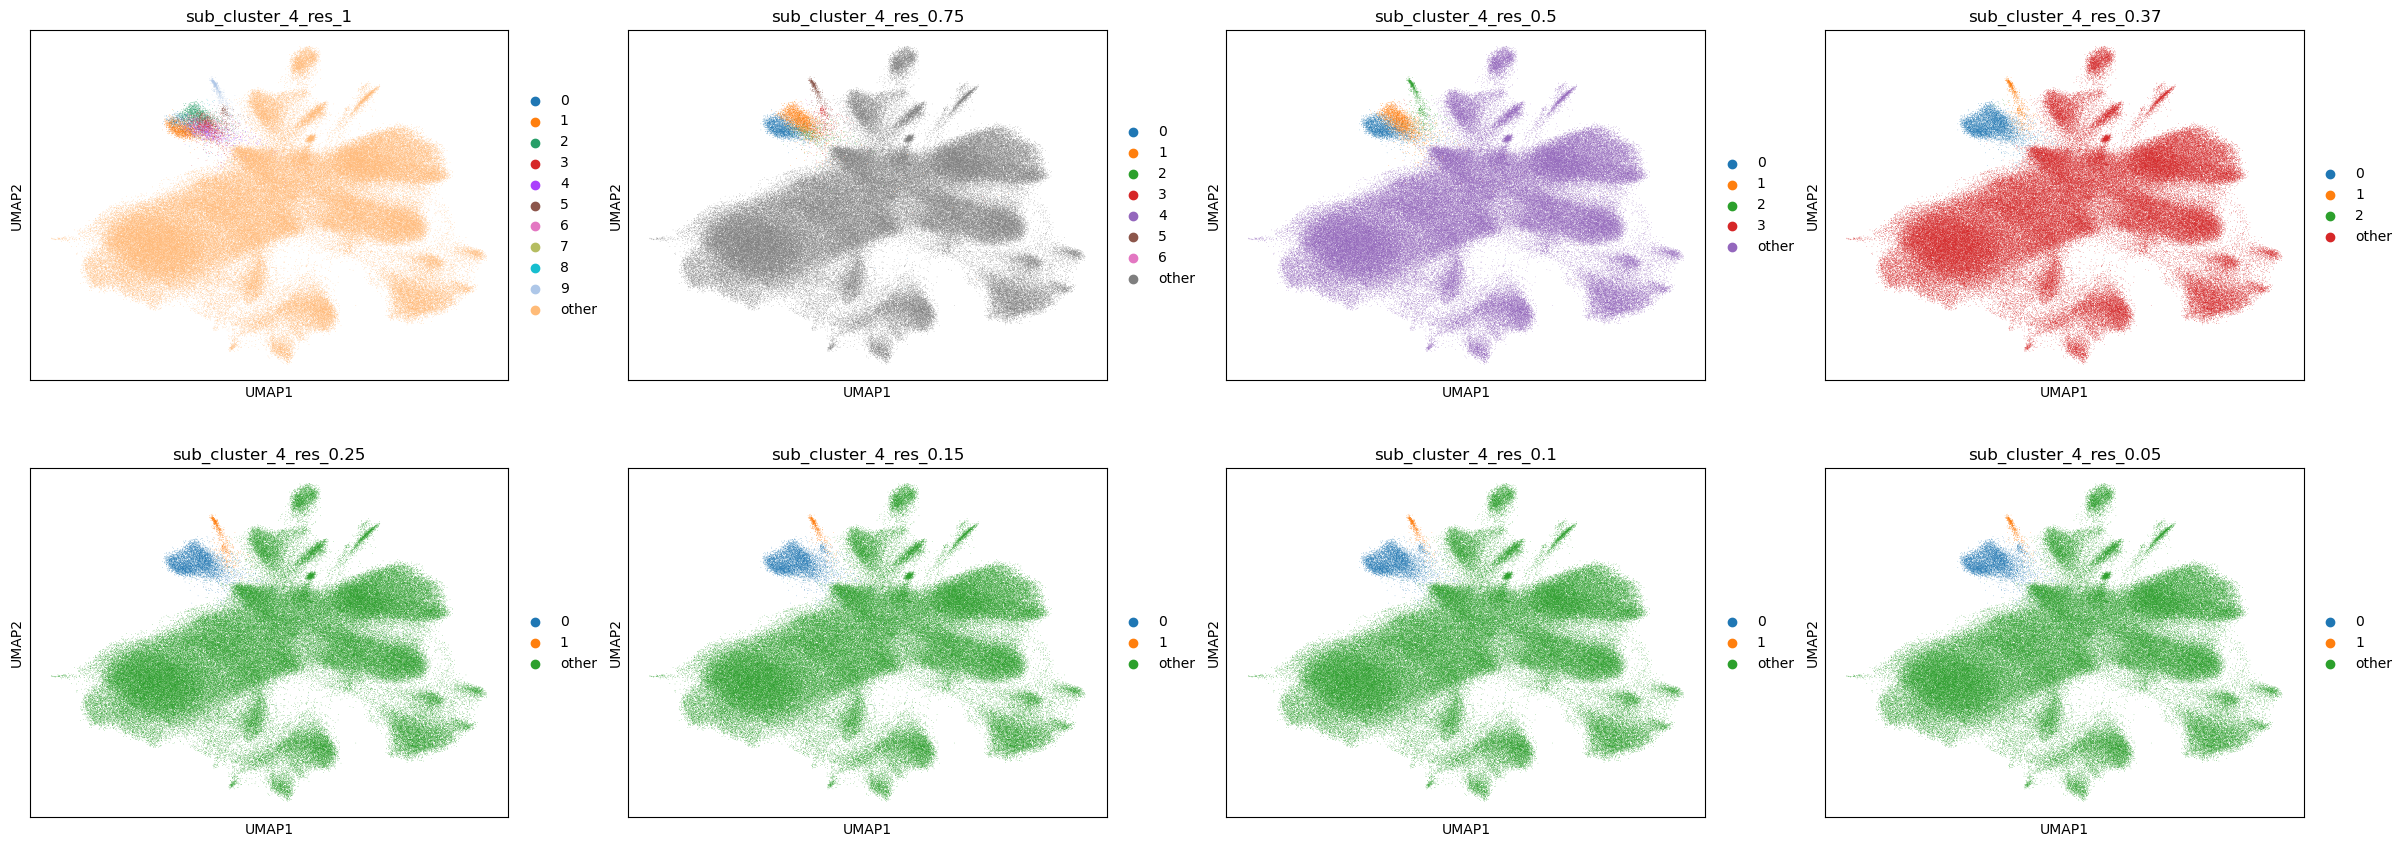

In [17]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [18]:
# ============================================================
# Time to assign  -  fine T-cell annotations from collaborator's notes.
# "We only want T cells": a cell is kept as a T cell ONLY if it lands in a
# subcluster she explicitly annotated. Everything else -- the contaminated CD4
# cluster(s) and any un-annotated CD8/CD4 subcluster -- is contamination/noise
# and set to 'other' at ALL tiers (Tier1 is removed for noise, not just Tier3).
#
# IMPORTANT: the sub-resolutions below MUST match those used in the subcluster
# loop above (sub_resolutions). We build the column via sub_res_label() and
# assert it exists so a resolution mismatch fails loudly instead of mislabeling.
# ============================================================

# --- CD8 subcluster annotations ---
cd8_sub_res = 0.75
cd8_labels = {'0': 'Effector CD8 T cell', '6': 'Proliferating CD8 T cell'}

# --- CD4 subcluster annotations ---  (None => CD4 is contamination)
cd4_sub_res = None
cd4_labels = {}

cd8_sub_col = sub_res_label(cd8_sub_res, cd8) if cd8_sub_res is not None else None
cd4_sub_col = sub_res_label(cd4_sub_res, cd4) if cd4_sub_res is not None else None
if cd8_sub_col is not None:
    assert cd8_sub_col in adata.obs, f"{cd8_sub_col} missing -- run the CD8 subcluster loop at res {cd8_sub_res}"
if cd4_sub_col is not None:
    assert cd4_sub_col in adata.obs, f"{cd4_sub_col} missing -- run the CD4 subcluster loop at res {cd4_sub_res}"

# Tier3: fine functional label, only for annotated subclusters
adata.obs['Tier3'] = 'other'
if cd8_sub_col is not None:
    for clust, label in cd8_labels.items():
        adata.obs.loc[adata.obs[cd8_sub_col] == clust, 'Tier3'] = label
if cd4_sub_col is not None:
    for clust, label in cd4_labels.items():
        adata.obs.loc[adata.obs[cd4_sub_col] == clust, 'Tier3'] = label
adata.obs['Tier3'] = adata.obs['Tier3'].astype('category')

# A cell is a real T cell iff it received a Tier3 label.
is_tcell = adata.obs['Tier3'] != 'other'

# Tier2: CD8- vs CD4-origin, only for confirmed T cells
adata.obs['Tier2'] = 'other'
if cd8_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd8_sub_col].isin(list(cd8_labels)), 'Tier2'] = 'CD8 T Cell'
if cd4_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd4_sub_col].isin(list(cd4_labels)), 'Tier2'] = 'CD4 T Cell'
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier1: 'T Cell' ONLY where a fine label was assigned (noise/contamination dropped)
adata.obs['Tier1'] = np.where(is_tcell, 'T Cell', 'other')
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Keep the exploratory boolean flags consistent with the cleaned annotation
adata.obs['t_cell'] = is_tcell
adata.obs['cd8'] = adata.obs['Tier2'] == 'CD8 T Cell'
adata.obs['cd4'] = adata.obs['Tier2'] == 'CD4 T Cell'

print("Tier1:\n", adata.obs['Tier1'].value_counts())
print("\nTier2:\n", adata.obs['Tier2'].value_counts())
print("\nTier3:\n", adata.obs['Tier3'].value_counts())


Tier1:
 Tier1
other     190549
T Cell      2451
Name: count, dtype: int64

Tier2:
 Tier2
other         190549
CD8 T Cell      2451
Name: count, dtype: int64

Tier3:
 Tier3
other                       190549
Effector CD8 T cell           2432
Proliferating CD8 T cell        19
Name: count, dtype: int64


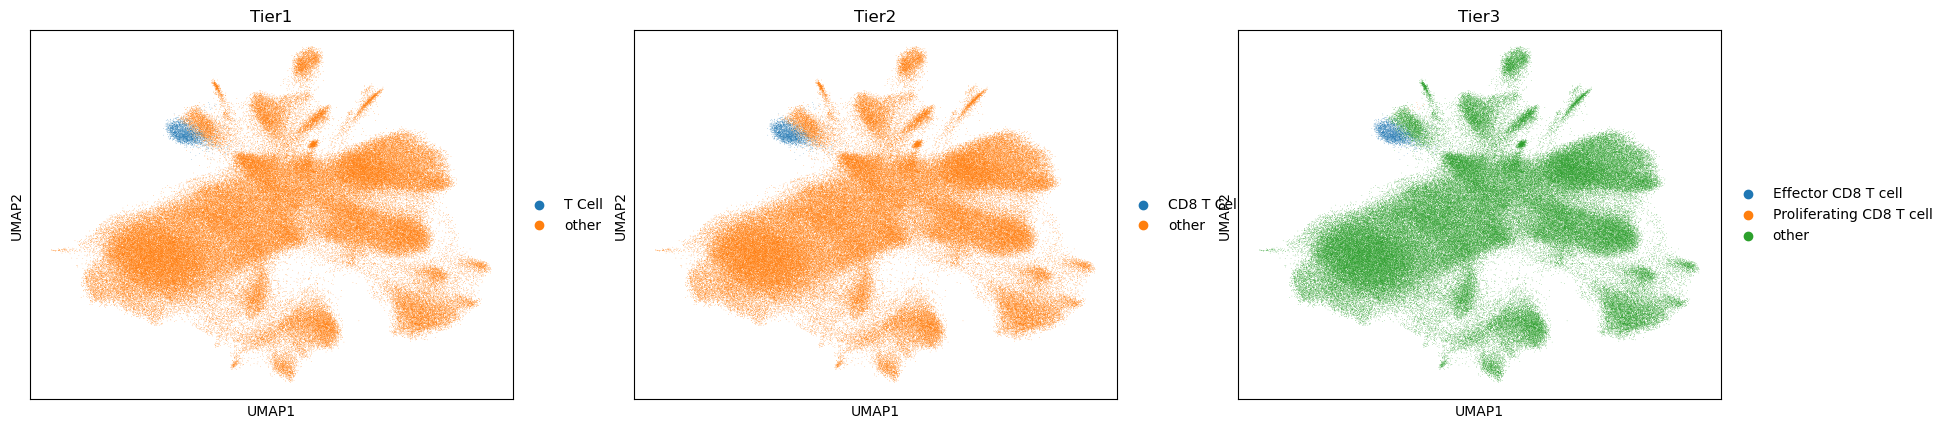

In [19]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [20]:
adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')